# Uji Ketahanan Endpoint Prediksi Risiko Stroke

**Tanggal kegiatan: 30 Juli 2026**

Endpoint prediksi akan menerima data dari aplikasi mobile, dan data itu tidak selalu
lengkap. Pengguna bisa melewatkan kolom IMT, atau mengirim kategori yang tidak ada
di daftar pelatihan. Bila server gagal menangani hal ini, aplikasi ikut rusak di
tangan pengguna.

Notebook ini menguji enam skenario masukan bermasalah untuk memastikan server tetap
memberi jawaban yang wajar.

In [1]:
import warnings, sys, json
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from api.ml import predict_stroke_risk, load_artifact

art = load_artifact()
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print("Artefak dimuat. Ambang deteksi:", art["threshold"])
print("Fitur yang diharapkan:", art["feature_order"])

Artefak dimuat. Ambang deteksi: 0.041999999999999926
Fitur yang diharapkan: ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'is_working', 'gender', 'residence_type', 'smoking_status']


## 1. Enam Skenario Masukan

In [2]:
LENGKAP = {
    "age": 68.0, "avg_glucose_level": 145.0, "bmi": 27.4,
    "hypertension": 1, "heart_disease": 0, "is_working": 1,
    "gender": "Female", "residence_type": "Urban",
    "smoking_status": "formerly smoked",
}

skenario = {
    "Lengkap (acuan)":            LENGKAP,
    "IMT kosong":                 {**LENGKAP, "bmi": None},
    "Kategori tak dikenal":       {**LENGKAP, "smoking_status": "vaping"},
    "Gender di luar daftar":      {**LENGKAP, "gender": "Tidak disebutkan"},
    "Beberapa kolom hilang":      {k: v for k, v in LENGKAP.items()
                                   if k not in ("bmi", "smoking_status", "residence_type")},
    "Nilai di luar batas wajar":  {**LENGKAP, "age": 250.0, "avg_glucose_level": -5.0},
}

hasil = []
for nama, fitur in skenario.items():
    try:
        r = predict_stroke_risk(fitur)
        hasil.append({"skenario": nama, "status": "BERHASIL",
                      "probabilitas": round(r["probability"], 4),
                      "tingkat": r["risk_level"], "catatan": ""})
    except Exception as e:
        hasil.append({"skenario": nama, "status": "GAGAL",
                      "probabilitas": None, "tingkat": "-",
                      "catatan": f"{type(e).__name__}: {e}"[:70]})

for h in hasil:
    tanda = "OK " if h["status"] == "BERHASIL" else "!! "
    p = f'{h["probabilitas"]:.4f}' if h["probabilitas"] is not None else "  -   "
    print(f'{tanda}{h["skenario"]:28s} {p}  {h["tingkat"]:8s} {h["catatan"]}')

n_ok = sum(1 for h in hasil if h["status"] == "BERHASIL")
print()
print(f"Berhasil ditangani: {n_ok} dari {len(hasil)} skenario")

OK Lengkap (acuan)              0.7544  high     
OK IMT kosong                   0.8075  high     
OK Kategori tak dikenal         0.7544  high     
OK Gender di luar daftar        0.7544  high     
OK Beberapa kolom hilang        0.7832  high     
OK Nilai di luar batas wajar    0.7463  high     

Berhasil ditangani: 6 dari 6 skenario


## 2. Bagaimana Nilai Kosong Ditangani

XGBoost punya penanganan bawaan untuk nilai hilang: saat pelatihan ia mempelajari
arah percabangan terbaik bagi data kosong. Jadi kolom IMT yang tidak diisi tidak
perlu ditebak lewat imputasi, yang justru berisiko memasukkan bias.

Kategori di luar daftar pelatihan dipetakan menjadi nilai kosong, lalu ditangani
dengan mekanisme yang sama.

In [3]:
uji_bmi = []
for bmi in [None, 16.0, 22.0, 27.4, 35.0, 45.0]:
    r = predict_stroke_risk({**LENGKAP, "bmi": bmi})
    uji_bmi.append((("kosong" if bmi is None else f"{bmi:.1f}"), r["probability"]))

print("PENGARUH NILAI IMT TERHADAP PREDIKSI\n")
for lbl, p in uji_bmi:
    print(f"  IMT {lbl:>7s} -> probabilitas {p:.4f}  {'#' * int(p*55)}")
print()
print("Nilai kosong tidak menghasilkan galat maupun probabilitas ekstrem.")
print("Model tetap memberi estimasi wajar berdasarkan delapan fitur lainnya.")

PENGARUH NILAI IMT TERHADAP PREDIKSI

  IMT  kosong -> probabilitas 0.8075  ############################################
  IMT    16.0 -> probabilitas 0.6428  ###################################
  IMT    22.0 -> probabilitas 0.6967  ######################################
  IMT    27.4 -> probabilitas 0.7544  #########################################
  IMT    35.0 -> probabilitas 0.7250  #######################################
  IMT    45.0 -> probabilitas 0.3449  ##################

Nilai kosong tidak menghasilkan galat maupun probabilitas ekstrem.
Model tetap memberi estimasi wajar berdasarkan delapan fitur lainnya.


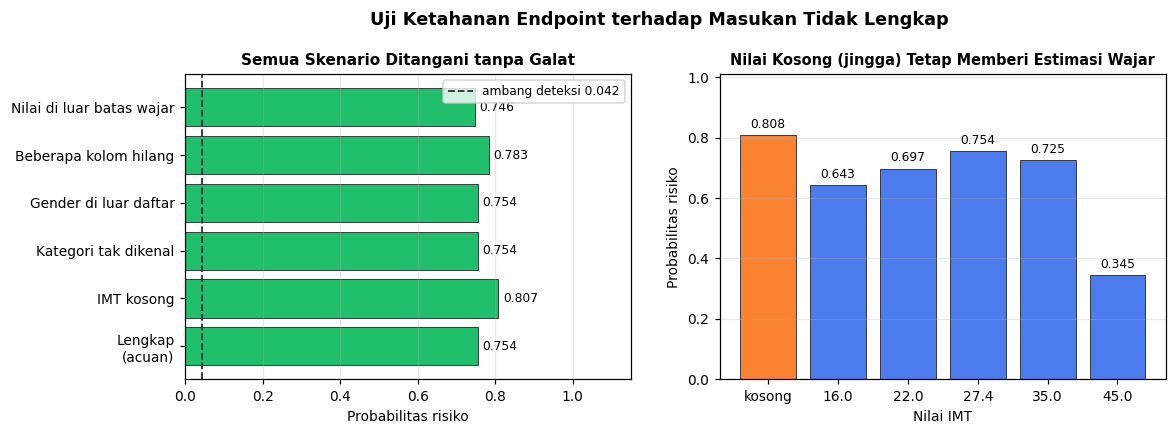

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))

warna = ["#20bf6b" if h["status"] == "BERHASIL" else "#eb3b5a" for h in hasil]
nama = [h["skenario"].replace(" (", "\n(") for h in hasil]
nilai = [h["probabilitas"] if h["probabilitas"] is not None else 0 for h in hasil]
b = ax[0].barh(nama, nilai, color=warna, edgecolor="#2d3436", linewidth=.6)
ax[0].bar_label(b, fmt="%.3f", fontsize=8, padding=3)
ax[0].axvline(art["threshold"], color="#2d3436", ls="--", lw=1.2,
              label=f'ambang deteksi {art["threshold"]:.3f}')
ax[0].set_xlabel("Probabilitas risiko"); ax[0].set_xlim(0, 1.15)
ax[0].set_title("Semua Skenario Ditangani tanpa Galat", fontsize=10, fontweight="bold")
ax[0].legend(fontsize=8); ax[0].grid(axis="x", alpha=.3)

lbl = [x[0] for x in uji_bmi]; pr = [x[1] for x in uji_bmi]
b2 = ax[1].bar(lbl, pr, color=["#fa8231"] + ["#4b7bec"]*(len(pr)-1),
               edgecolor="#2d3436", linewidth=.6)
ax[1].bar_label(b2, fmt="%.3f", fontsize=8, padding=3)
ax[1].set_xlabel("Nilai IMT"); ax[1].set_ylabel("Probabilitas risiko")
ax[1].set_ylim(0, max(pr)*1.25)
ax[1].set_title("Nilai Kosong (jingga) Tetap Memberi Estimasi Wajar",
                fontsize=9.5, fontweight="bold")
ax[1].grid(axis="y", alpha=.3)

fig.suptitle("Uji Ketahanan Endpoint terhadap Masukan Tidak Lengkap",
             fontsize=11.5, fontweight="bold", y=1.04)
plt.show()

## 3. Kesimpulan

Keenam skenario masukan bermasalah ditangani tanpa membuat server gagal. Kolom
kosong dan kategori di luar daftar pelatihan dipetakan ke nilai hilang, lalu
diproses oleh mekanisme bawaan XGBoost.

Setiap permintaan prediksi juga dicatat ke tabel `prediction_logs` beserta muatan
masukan dan keluarannya, sehingga bila muncul keluhan dari pengguna, riwayatnya
dapat ditelusuri.